# **E-Commerce Customer Segmentation and CRM Analytics Dashboard - Behavioral Customer Segmentation and Retention Risk Analysis**

---

> **The aim of this notebook:**
> - Segment customers based on behavioral, value, and engagement characteristics
> - Analyze customer patterns that are relevant to revenue quality and retention outcomes
> - Identify differences in spending, purchase frequency, loyalty, promotion dependency, and risk behavior across customer groups
> - Detect early retention risk signals such as weak engagement, cart abandonment, return behavior, and unstable value contribution
> - Compare stable and at-risk customers to understand what differentiates healthy customers from potentially declining ones
> - Generate business insights that can support segmentation strategy, retention planning, and customer prioritization

> **Expected Output:**
> - A structured view of customer behavior across value, activity, engagement, and risk dimensions
> - Clear customer groupings based on spending behavior, purchase intensity, and behavioral patterns
> - Insights into revenue quality through value-related metrics such as monthly spend, lifetime value proxy, and risk-adjusted value
> - Identification of retention risk signals including abandonment behavior, return behavior, coupon dependency, and risk exposure
> - Group-level comparisons between stable customers and retention-risk customers
> - Segment profiles that highlight behavioral and commercial differences across customer groups
> - Business-focused insights to support retention actions, customer targeting, and segment-level strategy

## **Import Library**

---

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# For outlier handling & clustering
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set display options for better readability
from IPython.display import display

---

## **Data Loading & Preparation**

---

**Business question:**
Is the data ready for reliable customer segmentation and risk analysis?

---

In [ ]:
# Load the dataset
df = pd.read_csv(r"C:\Users\user\Documents\Coding\Portofolio\E-Commerce-Customer-Segmentation-and-CRM-Analytics-Dashboard\Dataset\customer_data_full.csv")
df.head()

,user_id,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,...,log_attention_score,log_engagement_spend,log_risk_spend,log_triple_interaction,log_spend_per_purchase,log_spend_efficiency,log_revenue_per_click,log_high_value_score,log_safe_revenue,log_profit_proxy
0,1,56,Female,Germany,Suburban,90860,Self-employed,Associate Degree,Single,0,...,8.243019,7.126397,6.455073,5.796828,6.400673,4.041827,7.785721,6.820160,7.479345,7.784473
1,2,69,Male,Japan,Suburban,35423,Unemployed,Bachelor,Single,1,...,6.278521,7.471438,7.218504,6.487406,5.641361,4.685665,7.510157,7.004259,7.735676,8.203030
2,3,46,Female,India,Urban,21467,Self-employed,Associate Degree,Married,1,...,7.748891,7.315253,6.762087,6.453940,5.325446,3.697019,6.238813,6.767173,7.075433,7.623642
3,4,32,Male,Canada,Urban,41770,Self-employed,Bachelor,Widowed,0,...,7.912423,6.760281,6.814582,6.190047,4.621904,3.446688,6.692704,5.929631,6.553882,7.383989
4,7,78,Female,Germany,Urban,62804,Student,Bachelor,Widowed,1,...,6.413459,7.315374,6.583693,5.858465,5.964543,4.365325,6.943766,7.051031,7.777288,8.041091


In [ ]:
# Display the column names
df.columns.tolist()

In [ ]:
# Used columns for analysis
used_columns = [
    "user_id",
    "monthly_spend",
    "weekly_purchases",
    "average_order_value",
    "lifetime_value_proxy",
    "risk_adjusted_value",
    "spend_per_purchase",
    "daily_session_time_minutes",
    "product_views_per_day",
    "app_usage_frequency",
    "wishlist_items_count",
    "notification_response_rate",
    "engagement_score",
    "browse_to_buy_ratio",
    "revenue_proxy",
    "adjusted_revenue",
    "revenue_efficiency",
    "return_rate",
    "return_frequency",
    "cart_abandonment_rate",
    "checkout_abandonments_per_month",
    "risk_score",
    "coupon_usage_frequency",
    "coupon_dependency",
    "churn_proxy",
    "stability_score",
    "retention_strength",
    "risk_exposure",
    "loyalty_program_member",
    "premium_subscription",
    "referral_count",
    "brand_loyalty_score",
    "age",
    "gender",
    "country",
    "urban_rural",
    "income_level",
    "employment_status",
    "education_level",
    "household_size"
]

df_segment = df[[col for col in used_columns if col in df.columns]]
df_segment.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692978 entries, 0 to 692977
Data columns (total 40 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   user_id                          692978 non-null  int64  
 1   monthly_spend                    692978 non-null  int64  
 2   weekly_purchases                 692978 non-null  int64  
 3   average_order_value              692978 non-null  int64  
 4   lifetime_value_proxy             692978 non-null  int64  
 5   risk_adjusted_value              692978 non-null  float64
 6   spend_per_purchase               692978 non-null  float64
 7   daily_session_time_minutes       692978 non-null  int64  
 8   product_views_per_day            692978 non-null  int64  
 9   app_usage_frequency              692978 non-null  int64  
 10  wishlist_items_count             692978 non-null  int64  
 11  notification_response_rate       692978 non-null  int64  
 12  en

In [ ]:
# Missing value analysis 
missing_cols = [col for col in used_columns if col not in df_segment.columns]
if missing_cols:
    raise ValueError(f"The following columns were not found in the dataset: {missing_cols}")

print("Filtered shape:", df_segment.shape)
print("\nMissing values:")
display(df_segment.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

Filtered shape: (692978, 40)

Missing values:


,missing_count
user_id,0
monthly_spend,0
weekly_purchases,0
average_order_value,0
lifetime_value_proxy,0
...,...
urban_rural,0
income_level,0
employment_status,0
education_level,0


In [ ]:
# Duplicate value analysis
duplicated_columns = [col for col in used_columns if col not in df_segment.columns]
if duplicated_columns:
    raise ValueError(f"The following columns were not found in the dataset: {duplicated_columns}")

# Search for duplicates based on the used columns
dup_mask = df_segment.duplicated(subset=used_columns, keep=False)

print("Filtered shape:", df_segment.shape)
print(f"\nTotal duplicated rows (based on used_columns): {dup_mask.sum()}")

print("\nDuplicate groups:")
display(
    df_segment.loc[dup_mask, used_columns]
    .value_counts()
    .reset_index(name="duplicate_count")
    .sort_values("duplicate_count", ascending=False)
)

print("\nDuplicated rows:")
display(
    df_segment.loc[dup_mask]
    .sort_values(by=used_columns)
)

Filtered shape: (692978, 40)

Total duplicated rows (based on used_columns): 0

Duplicate groups:

Duplicated rows:


,user_id,monthly_spend,weekly_purchases,average_order_value,lifetime_value_proxy,risk_adjusted_value,spend_per_purchase,daily_session_time_minutes,product_views_per_day,app_usage_frequency,...,brand_loyalty_score,age,gender,country,urban_rural,income_level,employment_status,education_level,household_size,duplicate_count
,user_id,monthly_spend,weekly_purchases,average_order_value,lifetime_value_proxy,risk_adjusted_value,spend_per_purchase,daily_session_time_minutes,product_views_per_day,app_usage_frequency,...,referral_count,brand_loyalty_score,age,gender,country,urban_rural,income_level,employment_status,education_level,household_size


**Insight:**

The dataset is ready for use and further analysis. It contains a total of 166 columns. Based on the duplication assessment, 40 selected columns were used for validation, and 692,978 records were identified as non-duplicated. The columns used in this analysis are as follows:

| Column                            | Category                    | Used for                                                         | Why it matters                                                               |
| --------------------------------- | --------------------------- | ---------------------------------------------------------------- | ---------------------------------------------------------------------------- |
| `user_id`                         | Identifier                  | Customer-level identification, final output table, CRM targeting | Required to uniquely identify each customer                                  |
| `monthly_spend`                   | Value / Monetary            | FM segmentation, value profiling, spend analysis                 | Represents the customer’s recurring spending value                           |
| `weekly_purchases`                | Frequency                   | FM segmentation, purchase intensity analysis                     | Represents how frequently the customer makes purchases                       |
| `average_order_value`             | Value / Basket              | Basket analysis, transaction quality profiling                   | Explains the average value per transaction                                   |
| `lifetime_value_proxy`            | Value / Long-term           | Value profiling, segment comparison                              | Represents the customer’s estimated long-term value                          |
| `risk_adjusted_value`             | Value / Revenue Quality     | Revenue quality analysis, stable vs risky value comparison       | Shows customer value after accounting for risk                               |
| `spend_per_purchase`              | Value / Basket              | Basket behavior analysis                                         | Helps describe spending strength per transaction                             |
| `daily_session_time_minutes`      | Engagement / Activity       | Activity intensity analysis, behavioral segmentation             | Measures how long the customer stays engaged                                 |
| `product_views_per_day`           | Engagement / Activity       | Browsing behavior, pre-purchase analysis                         | Shows how intensively the customer explores products                         |
| `app_usage_frequency`             | Engagement / Activity       | Behavioral segmentation, usage consistency analysis              | Indicates how actively the customer uses the platform                        |
| `wishlist_items_count`            | Engagement / Interest       | Interest profiling, behavioral segmentation                      | Captures potential purchase intent                                           |
| `notification_response_rate`      | Engagement / Responsiveness | Marketing responsiveness analysis                                | Shows how customers react to business communication                          |
| `engagement_score`                | Engagement / Summary        | Segment profiling, stable vs at-risk comparison                  | Summarizes overall customer engagement quality                               |
| `browse_to_buy_ratio`             | Engagement / Conversion     | Conversion behavior analysis                                     | Measures how efficiently browsing turns into purchases                       |
| `revenue_proxy`                   | Revenue                     | Gross value analysis                                             | Provides a general view of revenue contribution                              |
| `adjusted_revenue`                | Revenue Quality             | Revenue quality comparison                                       | Reflects a cleaner or more realistic view of customer revenue                |
| `revenue_efficiency`              | Revenue Quality             | Efficiency analysis by customer/segment                          | Assesses how efficiently a customer generates revenue                        |
| `return_rate`                     | Leakage / Risk              | Revenue leakage analysis, risk scoring                           | A major signal of value leakage or unstable contribution                     |
| `return_frequency`                | Leakage / Risk              | Leakage profiling                                                | Adds context on how often purchases result in returns                        |
| `cart_abandonment_rate`           | Leakage / Funnel Risk       | Retention risk analysis, funnel weakness analysis                | Signals friction before the purchase is completed                            |
| `checkout_abandonments_per_month` | Leakage / Funnel Risk       | Retention risk scoring, leakage pressure analysis                | Shows the operational intensity of abandonment behavior                      |
| `risk_score`                      | Risk / Retention            | Retention risk framework, segment comparison                     | Serves as the core risk indicator for each customer                          |
| `coupon_usage_frequency`          | Risk / Promo Sensitivity    | Promotion dependency analysis                                    | Shows how often the customer relies on promotional incentives                |
| `coupon_dependency`               | Risk / Promo Sensitivity    | Retention risk analysis, margin quality analysis                 | Helps identify customers whose value may be fragile due to discount reliance |
| `churn_proxy`                     | Risk / Retention            | Early risk signal analysis                                       | Provides an early signal of potential customer decline                       |
| `stability_score`                 | Risk / Retention            | Stable vs unstable customer profiling                            | Indicates how stable the customer’s behavior or contribution is              |
| `retention_strength`              | Risk / Retention            | Customer health analysis, risk flagging                          | Reflects how strong the customer is in terms of retention                    |
| `risk_exposure`                   | Risk / Retention            | Risk prioritization, segment profiling                           | Shows the customer’s level of exposure to risk factors                       |
| `loyalty_program_member`          | Loyalty / Relationship      | Loyalty profiling, business action design                        | Indicates formal attachment to the brand or loyalty program                  |
| `premium_subscription`            | Loyalty / Relationship      | Premium customer analysis, segment profiling                     | Reflects a deeper commercial relationship with the customer                  |
| `referral_count`                  | Loyalty / Advocacy          | Loyalty strength, advocacy analysis                              | Captures customer contribution beyond direct purchases                       |
| `brand_loyalty_score`             | Loyalty / Relationship      | Loyalty segmentation, stable vs at-risk comparison               | Summarizes the customer’s loyalty to the brand                               |
| `age`                             | Customer Profile            | Segment profiling                                                | Provides age context for each segment                                        |
| `gender`                          | Customer Profile            | Segment profiling                                                | Helps describe segment composition                                           |
| `country`                         | Customer Profile            | Geographic profiling, localization insight                       | Supports interpretation across markets or regions                            |
| `urban_rural`                     | Customer Profile            | Geographic profiling                                             | Adds location context to customer behavior                                   |
| `income_level`                    | Customer Profile            | Value interpretation, segment profiling                          | Provides purchasing power context                                            |
| `employment_status`               | Customer Profile            | Customer profiling                                               | Adds economic context to customer behavior                                   |
| `education_level`                 | Customer Profile            | Customer profiling                                               | Supports socio-demographic interpretation of segments                        |
| `household_size`                  | Customer Profile            | Segment interpretation                                           | Adds context on household needs and spending patterns                        |

---

### **Capping Data**

---

In [ ]:
# Define column lists
numeric_cols = [
    "monthly_spend", "weekly_purchases", "average_order_value",
    "lifetime_value_proxy", "risk_adjusted_value", "spend_per_purchase",
    "daily_session_time_minutes", "product_views_per_day", "app_usage_frequency",
    "wishlist_items_count", "notification_response_rate", "engagement_score",
    "browse_to_buy_ratio", "revenue_proxy", "adjusted_revenue",
    "revenue_efficiency", "return_rate", "return_frequency",
    "cart_abandonment_rate", "checkout_abandonments_per_month",
    "risk_score", "coupon_usage_frequency", "coupon_dependency",
    "churn_proxy", "stability_score", "retention_strength",
    "risk_exposure", "referral_count", "brand_loyalty_score",
    "age", "household_size"
]

binary_cols = ["loyalty_program_member", "premium_subscription"]

categorical_cols = [
    "gender", "country", "urban_rural", "income_level",
    "employment_status", "education_level"
]

# Convert numeric columns to appropriate types and handle errors 
for col in numeric_cols:
    df_segment[col] = pd.to_numeric(df_segment[col], errors="coerce")

for col in binary_cols:
    df_segment[col] = pd.to_numeric(df_segment[col], errors="coerce")

C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_nWHF_.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment[col] = pd.to_numeric(df_segment[col], errors="coerce")
C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_nWHF_.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment[col] = pd.to_numeric(df_segment[col], errors="coerce")


In [ ]:
# Handle missing values
df_segment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692978 entries, 0 to 692977
Data columns (total 40 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   user_id                          692978 non-null  int64  
 1   monthly_spend                    692978 non-null  int64  
 2   weekly_purchases                 692978 non-null  int64  
 3   average_order_value              692978 non-null  int64  
 4   lifetime_value_proxy             692978 non-null  int64  
 5   risk_adjusted_value              692978 non-null  float64
 6   spend_per_purchase               692978 non-null  float64
 7   daily_session_time_minutes       692978 non-null  int64  
 8   product_views_per_day            692978 non-null  int64  
 9   app_usage_frequency              692978 non-null  int64  
 10  wishlist_items_count             692978 non-null  int64  
 11  notification_response_rate       692978 non-null  int64  
 12  en

In [ ]:
# Winsorize numeric columns to handle outliers
def winsorize_series(s, lower=0.01, upper=0.99):
    low = s.quantile(lower)
    high = s.quantile(upper)
    return s.clip(lower=low, upper=high)

winsor_cols = [
    "monthly_spend", "weekly_purchases", "lifetime_value_proxy",
    "risk_adjusted_value", "daily_session_time_minutes",
    "product_views_per_day", "revenue_proxy", "adjusted_revenue",
    "return_rate", "cart_abandonment_rate", "risk_score",
    "coupon_dependency", "risk_exposure"
]

for col_1 in winsor_cols:
    df_segment[col_1] = winsorize_series(df_segment[col_1])

print("Prepared shape:", df_segment.shape)
print("\nMissing values after preparation:")
print(df_segment.isna().sum().sort_values(ascending=False).head(10))

C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_ZHCJ_.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment[col_1] = winsorize_series(df_segment[col_1])
C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_ZHCJ_.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment[col_1] = winsorize_series(df_segment[col_1])
C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_ZHCJ_.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF

Prepared shape: (692978, 40)

Missing values after preparation:
user_id                       0
monthly_spend                 0
weekly_purchases              0
average_order_value           0
lifetime_value_proxy          0
risk_adjusted_value           0
spend_per_purchase            0
daily_session_time_minutes    0
product_views_per_day         0
app_usage_frequency           0
dtype: int64


**Insight:**

Winsorization is applied so that extremely large or unusual values:

* do not dominate customer segmentation
* do not distort segment averages
* do not bias value or risk scores too heavily
* remain in the dataset without being fully removed

So these columns are not winsorized because they are weak variables, but because they are **important variables that are highly sensitive to outliers**.

---

**Why each of these columns is winsorized**

| Column                       | Why it is winsorized                                                                                                                                 |
| ---------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- |
| `monthly_spend`              | Spending data is usually highly skewed. A small number of very high spenders can pull value segmentation too strongly toward extreme customers.      |
| `weekly_purchases`           | Some customers may purchase far more frequently than the rest of the population. Without winsorization, they can distort the frequency distribution. |
| `lifetime_value_proxy`       | Lifetime value usually follows a long-tail distribution. A small set of customers with very high estimated value can dominate segment profiles.      |
| `risk_adjusted_value`        | Since this is a derived value metric, it can also become extreme. Winsorization helps keep value comparisons more stable.                            |
| `daily_session_time_minutes` | Some users may show abnormally high session times due to unusual behavior or tracking noise. This can distort engagement analysis.                   |
| `product_views_per_day`      | Browsing intensity often contains extreme values, such as customers viewing far more products than normal.                                           |
| `revenue_proxy`              | Revenue-related variables are often heavy-tailed. Large outliers can make revenue-based comparisons less representative of the customer base.        |
| `adjusted_revenue`           | Even though it is a cleaner version of revenue, it can still contain extreme values that affect revenue quality analysis.                            |
| `return_rate`                | Some customers may have exceptionally high return behavior. Without mild capping, they can overinflate leakage and retention-risk measures.          |
| `cart_abandonment_rate`      | Like return rate, abandonment can be extremely high for a small number of customers, which can distort segment and risk profiling.                   |
| `risk_score`                 | As a core risk indicator, extreme values can cause retention risk scoring to be overly driven by one component.                                      |
| `coupon_dependency`          | Some customers may rely very heavily on promotions. Winsorization keeps that signal visible without allowing it to dominate the analysis.            |
| `risk_exposure`              | This variable directly affects risk prioritization. Extreme values can make classification overly aggressive if left untreated.                      |

---

**Why not winsorize all numeric columns?**

Because doing so would risk over-smoothing the dataset.

If too many variables are winsorized:

* real business differences may become muted
* meaningful customer variation may be flattened
* the analysis may become too “clean” and less realistic

That is why the approach is selective:
**only important numeric variables with strong outlier risk are winsorized.**

---

**Business context**

In customer analytics, outliers are often real, such as:

* very high spenders
* ultra-frequent buyers
* highly risky customers
* extremely promotion-dependent users
* customers with unusually intense browsing behavior

If these are left untreated:

* segments may be driven by a very small extreme minority
* average segment profiles may become misleading
* retention risk scores may become exaggerated
* clustering methods such as KMeans may focus too much on extreme points instead of broader customer patterns

Winsorization helps keep the analysis:

* more robust
* more representative
* easier to translate into business strategy

---

**Theoretical basis**

**1. It reduces the influence of outliers**

Many customer-related variables such as:

* `monthly_spend`
* `lifetime_value_proxy`
* `product_views_per_day`
* `return_rate`

often have **skewed** or **heavy-tailed** distributions, meaning that a small number of customers have values far above the rest of the population.

If left untreated, these outliers can strongly distort:

* the mean
* the standard deviation
* composite scoring
* customer segmentation
* clustering methods such as **KMeans**

Winsorization is used to make the analysis more **robust** to those extreme values.

---

**2. It preserves all observations**

Unlike trimming or removing outliers, winsorization:

* keeps all rows in the dataset
* does not reduce the number of customers
* only limits the influence of extreme values

This is important in business analysis because extreme customers may still be meaningful and should not automatically be discarded.

---

**3. It keeps the main distribution representative**

Using the **1%–99%** range means that only the most extreme tails of the distribution are adjusted.

The benefit is that:

* **98% of the core data remains unchanged**
* the main customer pattern is preserved
* the results better represent the broader customer base rather than a small extreme minority

---

**4. It is useful for scoring and distance-based methods**

Winsorization is especially helpful when the analysis includes:

* **weighted scoring**
* **FM segmentation**
* **retention risk scoring**
* **KMeans clustering**

These methods are sensitive to large values. A single extreme observation can:

* pull cluster centroids
* overinflate a score
* distort segment profiles

---

**Why use quantiles instead of mean ± standard deviation?**

Because customer data is usually **not normally distributed**.
Quantile-based thresholds such as 1% and 99% are more appropriate for data that is:

* asymmetric
* long-tailed
* naturally prone to outliers

So quantile-based winsorization is generally more suitable for behavioral customer data than standard deviation rules.

---

**Why 1% and 99%?**

Because this is a **conservative approach**:

* it only affects the most extreme observations
* it is not overly aggressive
* it still preserves the real variation in the data

This makes it well suited for business-oriented notebooks that need stable but realistic results.

---

**Conclusion**

This function is used because:

* customer data often contains **extreme outliers**
* outliers can **distort segmentation, scoring, and clustering**
* winsorization makes the analysis more **stable, robust, and representative**
* all customers remain in the dataset

---

## **Business Feature Construction**

---

**Business question:**
How can raw variables be translated into business dimensions?

---

Individual columns are useful, but business stakeholders usually need a more compact view of customer behavior.

To make the analysis easier to explain, the notebook builds four business-friendly dimensions:

- **value_core** → economic contribution
- **behavior_core** → engagement and activity quality
- **leakage_pressure** → return and abandonment pressure
- **loyalty_strength** → relationship depth with the brand

These dimensions help connect raw metrics to strategic decisions.

---

In [ ]:
# Function to calculate weighted scores for different cores
def weighted_score(df_segment, cols, weights, scaler=None):
    scaler = scaler or MinMaxScaler()
    scaled = scaler.fit_transform(df_segment[cols])
    return np.dot(scaled, np.array(weights))

# Calculate core scores
df_segment["value_core"] = weighted_score(
    df_segment,
    ["monthly_spend", "lifetime_value_proxy", "risk_adjusted_value", "adjusted_revenue"],
    [0.35, 0.25, 0.20, 0.20]
)

# Calculate behavior core score
df_segment["behavior_core"] = weighted_score(
    df_segment,
    [
        "daily_session_time_minutes", "product_views_per_day", "app_usage_frequency",
        "wishlist_items_count", "notification_response_rate", "engagement_score",
        "browse_to_buy_ratio"
    ],
    [0.20, 0.15, 0.15, 0.10, 0.15, 0.15, 0.10]
)

# Calculate leakage pressure score
df_segment["leakage_pressure"] = weighted_score(
    df_segment,
    [
        "cart_abandonment_rate", "checkout_abandonments_per_month",
        "return_rate", "return_frequency"
    ],
    [0.35, 0.25, 0.20, 0.20]
)

# Calculate loyalty strength score
df_segment["loyalty_strength"] = weighted_score(
    df_segment,
    [
        "loyalty_program_member", "premium_subscription",
        "referral_count", "brand_loyalty_score"
    ],
    [0.25, 0.20, 0.20, 0.35]
)

# Display summary statistics for the new core scores
df_segment[["value_core", "behavior_core", "leakage_pressure", "loyalty_strength"]].describe().T

C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_Vxnm_.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["value_core"] = weighted_score(
C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_Vxnm_.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["behavior_core"] = weighted_score(
C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_Vxnm_.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

,count,mean,std,min,25%,50%,75%,max
value_core,692978.0,0.333699,0.191348,0.000000,0.176936,0.322046,0.472530,1.000000
behavior_core,692978.0,0.500007,0.123994,0.036413,0.413788,0.499893,0.586252,0.961818
leakage_pressure,692978.0,0.487545,0.155053,0.000000,0.378048,0.487226,0.596587,0.997980
loyalty_strength,692978.0,0.472103,0.202715,0.000000,0.325000,0.470000,0.620000,1.000000


**Insight:**

**Composite Customer Scoring Framework**

To create a more actionable customer view, I developed four composite scores that summarize different dimensions of customer quality and business value:

* **Value Core**
* **Behavior Core**
* **Leakage Pressure**
* **Loyalty Strength**

Each score was built using **Min-Max normalization** and a **weighted scoring approach**. First, the selected variables were scaled into a common 0–1 range so that metrics with different units could be compared fairly. Then, each variable was combined using business-defined weights based on its relative importance.

Because all input features were normalized to a 0–1 scale and the weights for each score sum to 1, the final scores also fall roughly between **0 and 1**.

---

**1. Value Core**

**Mean: 0.334 | Median: 0.322**

The average Value Core is relatively low, which suggests that customer value is not evenly distributed across the population. This is common in customer data, where a large share of customers contribute moderate value, while a smaller group generates very high spend and lifetime value. After Min-Max scaling, those top customers move closer to 1, while the majority remain in the low-to-mid range. As a result, the overall average is pulled below the midpoint.

---

**2. Behavior Core**

**Mean: 0.500 | Median: 0.500**

The Behavior Core is centered almost exactly around 0.50, which indicates that customer activity and engagement are distributed more evenly than monetary value. Behavioral features such as session time, product views, app usage, and engagement tend to vary across the base in a more balanced way, so the final score naturally clusters around the middle.

---

**3. Leakage Pressure**

**Mean: 0.488 | Median: 0.487**

Leakage Pressure is also close to the midpoint, which suggests that signals of revenue loss, such as abandonment and returns, are moderately present across the customer base. This means leakage risk is not isolated to a very small group, but is instead distributed across a broader portion of customers.

**4. Loyalty Strength**

**Mean: 0.472 | Median: 0.470**

The Loyalty Strength score is slightly below the midpoint. This indicates that loyalty exists in the customer base, but is not especially strong overall. This is also reasonable because some components, such as loyalty membership and premium subscription, are binary, while others like referral count are often highly skewed, with many customers showing limited loyalty behavior.

---

**Weighting rationale**

The weights were assigned using **business logic**, not purely statistical optimization. The goal was to reflect practical business priorities and create scores that are interpretable and useful for segmentation.

---

**1. Value Core**

**Variables:** monthly_spend, lifetime_value_proxy, risk_adjusted_value, adjusted_revenue

**Weights:** 0.35, 0.25, 0.20, 0.20

The largest weight was assigned to **monthly spend** because it represents the most direct and current contribution to revenue. **Lifetime value proxy** was weighted next to capture long-term customer importance. **Risk-adjusted value** and **adjusted revenue** were also included to reflect the quality and sustainability of value, rather than just top-line revenue.

---

**2. Behavior Core**

**Variables:** daily_session_time_minutes, product_views_per_day, app_usage_frequency, wishlist_items_count, notification_response_rate, engagement_score, browse_to_buy_ratio

**Weights:** 0.20, 0.15, 0.15, 0.10, 0.15, 0.15, 0.10

The highest weight was given to **daily session time** because it is a strong signal of customer activity intensity. Product views, app usage, notification response, and engagement score were weighted similarly because they reflect active interaction with the platform. Wishlist count and browse-to-buy ratio were included as supporting indicators of intent and conversion behavior.

**3. Leakage Pressure**

**Variables:** cart_abandonment_rate, checkout_abandonments_per_month, return_rate, return_frequency

**Weights:** 0.35, 0.25, 0.20, 0.20

**Cart abandonment rate** received the highest weight because it is one of the clearest indicators that purchase intent is not converting into revenue. **Checkout abandonment** was weighted next because it occurs even closer to the transaction stage. **Return rate** and **return frequency** were included to capture post-purchase revenue leakage.

**4. Loyalty Strength**

**Variables:** loyalty_program_member, premium_subscription, referral_count, brand_loyalty_score

**Weights:** 0.25, 0.20, 0.20, 0.35

The highest weight was given to **brand_loyalty_score** because it most directly reflects genuine customer affinity and commitment. **Loyalty program membership** and **premium subscription** represent formal participation, but being enrolled in a program does not always mean true loyalty. **Referral count** was included as a strong advocacy signal, although it tends to be less common across the full customer base.

---

**Key interpretation**

Overall, the results suggest that:

* **Customer value is concentrated in a smaller high-value group**
* **Behavior is more evenly distributed across the base**
* **Leakage signals are moderate and widely present**
* **Loyalty is visible, but not especially strong overall**

This scoring framework helps move beyond single metrics and provides a more structured way to assess customer quality from multiple angles. It is especially useful for segmentation, prioritization, and identifying customers who are valuable, behaviorally active, vulnerable to leakage, or strong in loyalty.

---

## **Formal FM Segmentation**

---

**Business question:**
Who buys often, and who spends the most?

---

FM segmentation is the most practical starting point for customer segmentation because it answers two direct commercial questions:

- **Frequency** → who buys often?
- **Monetary value** → who contributes more spend?

This creates a clear business foundation before moving into richer behavioral or risk-oriented segmentation.

### **FM scoring Framework Theoretical**

---

In [ ]:
# Display the first few rows of the F, M, and FM scores
df_segment[["weekly_purchases", "monthly_spend"]].head()

,weekly_purchases,monthly_spend
0,4,2405
1,13,3651
2,10,2045
3,16,1611
4,8,3107


In [ ]:
# Calculate F, M, and FM scores based on weekly purchases and monthly spend
df_segment["f_score"] = pd.qcut(
    df_segment["weekly_purchases"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Calculate M score based on monthly spend
df_segment["m_score"] = pd.qcut(
    df_segment["monthly_spend"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Calculate FM score by combining F and M scores
df_segment["fm_score"] = df_segment["f_score"].astype(str) + df_segment["m_score"].astype(str)

C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_aLJB_.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["f_score"] = pd.qcut(
C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_aLJB_.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["m_score"] = pd.qcut(
C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_aLJB_.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

In [ ]:
# Display the first few rows of the F, M, and FM scores
df_segment[["f_score", "m_score", "fm_score"]].head()

,f_score,m_score,fm_score
0,1,3,13
1,3,4,34
2,3,3,33
3,4,2,42
4,2,4,24


**Insight:**

This logic builds an **FM scoring framework**, where:

* **F (Frequency)** represents how often a customer purchases
* **M (Monetary)** represents how much a customer spends

In this case:

* Frequency is measured by **weekly purchases**
* Monetary is measured by **monthly spend**

The purpose is to classify customers based on **purchase intensity** and **economic contribution**.

---

**Explanation:**

First, customers are ranked by their purchase frequency and then divided into **five equal-sized groups**.
This creates a **frequency score from 1 to 5**, where:

* **1** = lowest frequency group
* **5** = highest frequency group

The same process is then applied to spending. Customers are ranked by monthly spend and divided into five groups, producing a **monetary score from 1 to 5**, where:

* **1** = lowest spending group
* **5** = highest spending group

After that, the two scores are combined into a single **FM label**.
For example:

* **55** means the customer is in the highest group for both frequency and spending
* **15** means low frequency but high spending
* **51** means high frequency but low spending
* **11** means low frequency and low spending

This combined score gives a more complete picture of customer behavior than looking at only one metric.

---

**Theoretical basis**

FM scoring comes from the broader **RFM framework** in customer analytics.
RFM stands for:

* **Recency**
* **Frequency**
* **Monetary**

Since this analysis does not use recency, it focuses on the two dimensions that are still highly valuable for segmentation:

* **Frequency**, which reflects customer activity and repeat buying behavior
* **Monetary**, which reflects customer value contribution

The use of **quantile-based grouping** means customers are scored based on their **relative position in the dataset**, not on fixed business thresholds. This is important because customer data is often uneven or skewed, so relative scoring produces more balanced and interpretable groups.

---

### **FM Segments**

---

In [ ]:
# Function to assign FM segments based on F and M scores 
def assign_fm_segment(row):
    f, m = row["f_score"], row["m_score"]
    if f >= 4 and m >= 4:
        return "High Frequency High Spend"
    elif f >= 4 and m <= 2:
        return "Frequent Low Basket"
    elif f <= 2 and m >= 4:
        return "High Spend Low Frequency"
    elif f <= 2 and m <= 2:
        return "Low Frequency Low Spend"
    else:
        return "Mid Value Regulars"

In [ ]:
# Assign FM segments to the DataFrame
df_segment["fm_segment"] = df_segment.apply(assign_fm_segment, axis=1)

fm_summary = (
    df_segment.groupby("fm_segment")
      .agg(
          customers=("user_id", "count"),
          avg_monthly_spend=("monthly_spend", "mean"),
          avg_weekly_purchases=("weekly_purchases", "mean"),
          avg_ltv=("lifetime_value_proxy", "mean"),
          avg_risk_adjusted_value=("risk_adjusted_value", "mean")
      )
      .sort_values("customers", ascending=False)
)

fm_summary["customer_share_pct"] = 100 * fm_summary["customers"] / len(df_segment)
fm_summary.round(2)

C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_NCOB_.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["fm_segment"] = df_segment.apply(assign_fm_segment, axis=1)


,customers,avg_monthly_spend,avg_weekly_purchases,avg_ltv,avg_risk_adjusted_value,customer_share_pct
fm_segment,,,,,,
Mid Value Regulars,249494,2500.46,10.50,31271.75,72083.28,36.00
Frequent Low Basket,111082,1002.35,16.50,12540.33,28907.74,16.03
High Spend Low Frequency,111067,4003.64,4.50,49913.23,114634.98,16.03
Low Frequency Low Spend,110688,998.82,4.50,12477.51,28685.40,15.97
High Frequency High Spend,110647,3998.74,16.51,49822.20,114890.01,15.97


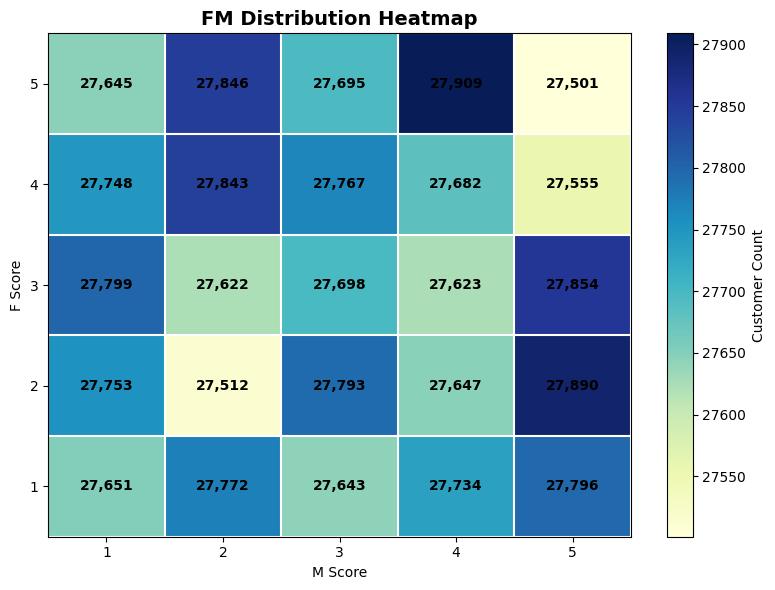

In [ ]:
# FM pivot table
fm_heatmap = pd.pivot_table(
    df_segment,
    values="user_id",
    index="f_score",
    columns="m_score",
    aggfunc="count",
    fill_value=0
)

# Convert to array
heatmap_values = fm_heatmap.values

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(heatmap_values, cmap="YlGnBu", origin="lower", aspect="auto")

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Customer Count")

# Axis ticks and labels
ax.set_xticks(np.arange(len(fm_heatmap.columns)))
ax.set_yticks(np.arange(len(fm_heatmap.index)))
ax.set_xticklabels(fm_heatmap.columns)
ax.set_yticklabels(fm_heatmap.index)

ax.set_xlabel("M Score")
ax.set_ylabel("F Score")
ax.set_title("FM Distribution Heatmap", fontsize=14, fontweight="bold")

# Add gridlines between cells
ax.set_xticks(np.arange(-0.5, len(fm_heatmap.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(fm_heatmap.index), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

# Add annotations inside each cell
for i in range(heatmap_values.shape[0]):
    for j in range(heatmap_values.shape[1]):
        value = heatmap_values[i, j]
        ax.text(
            j, i, f"{value:,}",
            ha="center", va="center",
            color="black", fontsize=10, fontweight="bold"
        )

plt.tight_layout()
plt.show()

**Insight:**


**1. Why does the FM heatmap look so balanced?**

Each cell in the heatmap contains about **27.5k–27.9k customers**, so the counts are very similar.

This likely happened because the **F Score** and **M Score** were created using a **quintile or ranking-based method**, where customers were divided into 5 groups of roughly equal size.

That means:

* **F = 1 to 5** each contains around 20% of customers
* **M = 1 to 5** also contains around 20%
* when combined into a 5x5 matrix, each cell also becomes relatively balanced

The heatmap does **not** mean that all customers are the same.
It means the scoring system split the population in a **fairly even and structured way**, which is useful for CRM analysis because no single group is overwhelmingly dominant.

---

**2. Interpretation of each FM segment**

**A. **Mid Value Regulars****

* **249,494 customers**
* **36.0%** of the customer base
* Avg monthly spend = **2,500.46**
* Avg weekly purchases = **10.5**
* Avg LTV = **31,271.75**
* Avg risk-adjusted value = **72,083.28**

This is the **core customer segment**.
They are not extreme in either spend or frequency, but they are steady in both.

**Business meaning**

* this is the largest segment
* very important for **retention**
* suitable for **light upsell**, **cross-sell**, and **engagement programs**
* they likely represent the main revenue engine because of their scale

---

**B. **Frequent Low Basket****

* **111,082 customers**
* **16.03%**
* Avg monthly spend = **1,002.35**
* Avg weekly purchases = **16.5**
* Avg LTV = **12,540.33**
* Avg risk-adjusted value = **28,907.74**

These customers **purchase often**, but spend relatively little each time.
They are active, but their monetary contribution per customer is low.

**Business meaning**

* strong segment for **habitual usage**
* suitable for:

  * bundling
  * minimum basket incentives
  * add-on product recommendations
  * complementary product suggestions
* the main goal is to **increase basket size / order value**

---

**C. **High Spend Low Frequency****

* **111,067 customers**
* **16.03%**
* Avg monthly spend = **4,003.64**
* Avg weekly purchases = **4.5**
* Avg LTV = **49,913.23**
* Avg risk-adjusted value = **114,634.98**

These customers **purchase less often**, but spend a lot when they do.

**Business meaning**

* they are a high-value segment
* better suited for:

  * personalized reminders
  * replenishment timing
  * premium recommendations
  * concierge-style targeting
* the main goal is to **increase purchase frequency without reducing basket value**

---

**D. **Low Frequency Low Spend****

* **110,688 customers**
* **15.97%**
* Avg monthly spend = **998.82**
* Avg weekly purchases = **4.5**
* Avg LTV = **12,477.51**
* Avg risk-adjusted value = **28,685.40**

This is the **lowest-value segment**:

* they buy infrequently
* and they spend little

**Business meaning**

* not the best segment for heavy investment
* more suitable for:

  * low-cost automation
  * limited promotions
  * lightweight reactivation
  * simple onboarding or nudges
* the main goal is to **test whether they can be activated**, without spending too much

---

**E. **High Frequency High Spend****

* **110,647 customers**
* **15.97%**
* Avg monthly spend = **3,998.74**
* Avg weekly purchases = **16.51**
* Avg LTV = **49,822.20**
* Avg risk-adjusted value = **114,890.01**

This is the **best-performing segment**:

* high purchase frequency
* high spending
* high LTV
* highest risk-adjusted value

**Business meaning**

* this is the **VIP / top customer** group
* very important for:

  * priority retention
  * premium service
  * exclusive rewards
  * proactive service recovery
* the main goal is to **protect value and prevent churn or leakage**

---

**3. Main insights from your FM segmentation**

**Insight 1 — The customer base is well distributed**

The segmentation creates a clean structure:

* 1 large core segment: **Mid Value Regulars**
* 4 additional segments, each representing about **16%**

This is a healthy setup because the customer base includes:

* core customers
* premium customers
* active but low-value customers
* lower-value, lower-frequency customers

---

**Insight 2 — Frequency and spend create clear behavioral patterns**

The results show four clear customer types:

* **high frequency + high spend** → High Frequency High Spend
* **high frequency + low spend** → Frequent Low Basket
* **low frequency + high spend** → High Spend Low Frequency
* **low frequency + low spend** → Low Frequency Low Spend

This is highly useful for CRM because each group needs a different strategy.

---

**Insight 3 — There are two types of high-value customers**

High-value customers are not just one group:

* **High Frequency High Spend**
* **High Spend Low Frequency**

This means high customer value can come from:

* loyal shoppers who buy frequently
* big spenders who buy less often but place large orders

So retention strategy should not treat all valuable customers the same way.

---

**Insight 4 — Mid Value Regulars are the backbone of the business**

Even though they are not the highest-value customers on a per-customer basis, they:

* are the largest group
* show stable behavior
* likely contribute a large share of total revenue

---

**4. Business implications**

**Priority 1 — Protect **High Frequency High Spend****

Actions:

* VIP retention
* premium service
* exclusive rewards
* early-warning monitoring

**Priority 2 — Increase frequency in **High Spend Low Frequency****

Actions:

* personalized reminders
* replenishment timing
* premium cross-sell
* lifecycle triggers

**Priority 3 — Increase basket size in **Frequent Low Basket****

Actions:

* bundling
* product recommendations
* threshold-based incentives
* cart expansion strategy

**Priority 4 — Grow **Mid Value Regulars****

Actions:

* loyalty development
* selective upsell
* engagement nurturing
* move them toward higher-value segments

**Priority 5 — Manage **Low Frequency Low Spend** efficiently****

Actions:

* low-cost campaigns
* simple reactivation
* avoid over-investment

---

## **Behavioral Customer Segmentation**

---

**Business question:**
Which customer groups matter beyond simple frequency and spend?

---

In [ ]:
# Define quantile-based labeling function for core scores
def qlabel(series, labels=("Low", "Medium", "High")):
    return pd.qcut(series.rank(method="first"), q=3, labels=labels)

df_segment["value_band"] = qlabel(df_segment["value_core"])
df_segment["behavior_band"] = qlabel(df_segment["behavior_core"])
df_segment["leakage_band"] = qlabel(df_segment["leakage_pressure"])
df_segment["loyalty_band"] = qlabel(df_segment["loyalty_strength"])

# Define function to assign behavior segments based on core bands and coupon dependency
coupon_high_threshold = df_segment["coupon_dependency"].quantile(0.67)

C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_yCnT_.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["value_band"] = qlabel(df_segment["value_core"])
C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_yCnT_.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["behavior_band"] = qlabel(df_segment["behavior_core"])
C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_yCnT_.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

In [ ]:
# Function to assign behavior segments based on core bands and coupon dependency
df_segment[["value_band", "behavior_band", "leakage_band", "loyalty_band"]].head()

,value_band,behavior_band,leakage_band,loyalty_band
0,Medium,High,Low,High
1,High,Medium,High,Medium
2,Medium,High,Low,Low
3,Low,Medium,Medium,Low
4,High,Medium,Medium,Low


In [ ]:
# Define function to assign behavior segments based on core bands and coupon dependency
def assign_behavior_segment(row):
    if row["value_band"] == "High" and row["leakage_band"] == "Low" and row["loyalty_band"] in ["Medium", "High"]:
        return "Core Value Customers"
    elif row["behavior_band"] == "High" and row["loyalty_band"] == "High" and row["value_band"] in ["Medium", "High"]:
        return "Loyal Frequent Buyers"
    elif row["value_band"] == "High" and row["leakage_band"] == "High":
        return "High Value but Unstable"
    elif row["coupon_dependency"] >= coupon_high_threshold and row["value_band"] in ["Low", "Medium"]:
        return "Promo-Driven Customers"
    elif row["behavior_band"] == "High" and row["value_band"] == "Medium" and row["leakage_band"] in ["Low", "Medium"]:
        return "High Potential Customers"
    elif row["value_band"] == "Low" and row["behavior_band"] == "Low":
        return "Low Value Low Engagement"
    else:
        return "General Customers"

# Assign behavior segments to the DataFrame
df_segment["behavior_segment"] = df_segment.apply(assign_behavior_segment, axis=1)
df_segment["behavior_segment"].head()

C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_kqZH_.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["behavior_segment"] = df_segment.apply(assign_behavior_segment, axis=1)


,behavior_segment
0,Loyal Frequent Buyers
1,High Value but Unstable
2,High Potential Customers
3,Promo-Driven Customers
4,General Customers


In [ ]:
# Create behavior profile summary
behavior_profile = (
    df_segment.groupby("behavior_segment")
      .agg(
          customers=("user_id", "count"),
          avg_monthly_spend=("monthly_spend", "mean"),
          avg_weekly_purchases=("weekly_purchases", "mean"),
          avg_engagement=("engagement_score", "mean"),
          avg_coupon_dependency=("coupon_dependency", "mean"),
          avg_return_rate=("return_rate", "mean"),
          avg_cart_abandonment=("cart_abandonment_rate", "mean"),
          avg_risk_adjusted_value=("risk_adjusted_value", "mean")
      )
      .sort_values("customers", ascending=False)
)

behavior_profile["customer_share_pct"] = 100 * behavior_profile["customers"] / len(df)
behavior_profile.round(2)

,customers,avg_monthly_spend,avg_weekly_purchases,avg_engagement,avg_coupon_dependency,avg_return_rate,avg_cart_abandonment,avg_risk_adjusted_value,customer_share_pct
behavior_segment,,,,,,,,,
General Customers,271100,2911.77,10.40,0.52,0.00,49.72,39.54,81131.13,39.12
Promo-Driven Customers,211668,1140.80,10.36,0.53,0.01,50.32,40.46,30204.64,30.54
High Value but Unstable,64298,4019.17,11.21,0.51,0.00,60.81,58.59,109966.86,9.28
Core Value Customers,54378,3938.25,11.05,0.53,0.00,37.68,20.64,159984.88,7.85
Loyal Frequent Buyers,42166,3150.98,10.74,0.65,0.00,52.03,43.91,84920.20,6.08
Low Value Low Engagement,25388,1170.29,9.72,0.41,0.00,51.04,41.23,21827.60,3.66
High Potential Customers,23980,2788.43,10.17,0.65,0.00,44.80,31.55,63460.66,3.46


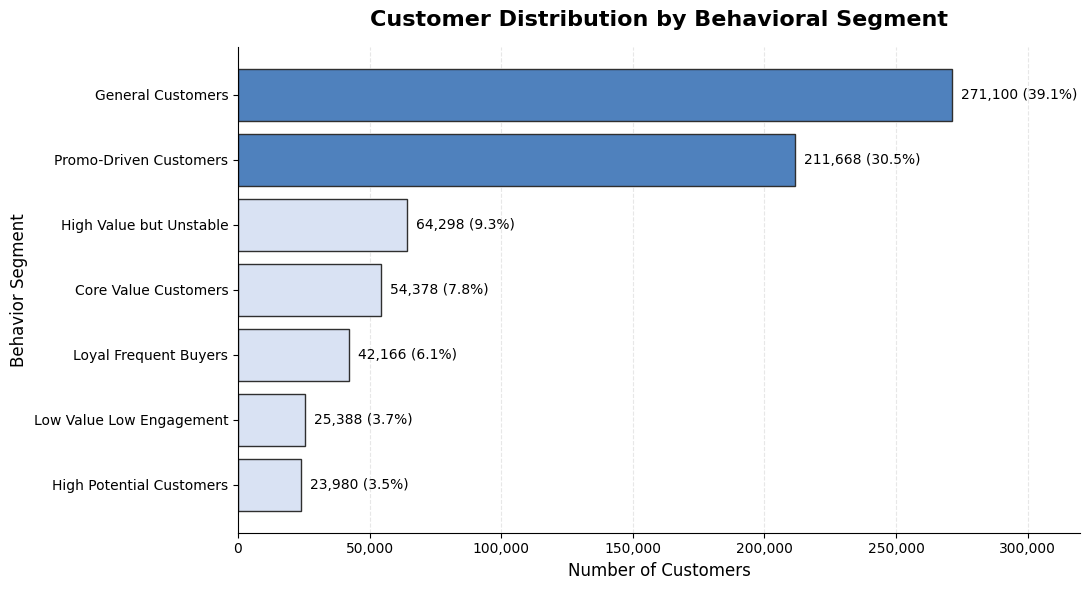

In [ ]:
# Create horizontal bar chart for behavior segment distribution
segment_counts = (
    df_segment["behavior_segment"]
    .value_counts()
    .sort_values(ascending=True)   # ascending supaya terbesar ada di atas setelah barh
)

total = segment_counts.sum()
percentages = segment_counts / total * 100

# Colors: highlight 2 largest segments
colors = ["#D9E2F3"] * len(segment_counts)
top_idx = np.argsort(segment_counts.values)[-2:]  # 2 terbesar
for i_1 in top_idx:
    colors[i_1] = "#4F81BD"

fig_1, ax_1 = plt.subplots(figsize=(11, 6))

bars = ax_1.barh(
    segment_counts.index,
    segment_counts.values,
    color=colors,
    edgecolor="#2F2F2F",
    linewidth=1
)

# Set title and labels
ax_1.set_title(
    "Customer Distribution by Behavioral Segment",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax_1.set_xlabel("Number of Customers", fontsize=12)
ax_1.set_ylabel("Behavior Segment", fontsize=12)

# Format x-axis with thousand separators
ax_1.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Grid 
ax_1.grid(axis="x", linestyle="--", alpha=0.3)
ax_1.set_axisbelow(True)

# Remove top and right spines for cleaner look
ax_1.spines["top"].set_visible(False)
ax_1.spines["right"].set_visible(False)

# Add value labels to the right of each bar
for bar, value_1, pct in zip(bars, segment_counts.values, percentages.values):
    ax_1.text(
        value_1 + total * 0.005,                      # sedikit di kanan bar
        bar.get_y() + bar.get_height() / 2,
        f"{value_1:,.0f} ({pct:.1f}%)",
        va="center",
        ha="left",
        fontsize=10
    )

# Set x-axis limit slightly above the largest segment for better label fit
ax_1.set_xlim(0, segment_counts.max() * 1.18)

plt.tight_layout()
plt.show()

**Insight:**

**1. Core Value Customers — most important overall**
This is the strongest segment because it combines:

* high spend
* solid frequency
* good engagement
* low abandonment
* low return rate
* the **highest risk-adjusted value**

**Why they matter:**
They generate high value, and that value is also more stable and reliable.

---

**2. High Value but Unstable — important but risky**

This segment has:

* the **highest spend**
* the **highest frequency**
* but also very high:

  * return rate
  * cart abandonment

**Why they matter:**
They look valuable on the surface, but their value is less secure because a large part of it is exposed to leakage.

---

**3. Loyal Frequent Buyers — important for retention**

This group stands out for:

* very high engagement
* strong activity
* relatively good value

**Why they matter:**
They are behaviorally strong and likely important for long-term retention and relationship building.

---

**4. High Potential Customers — important for growth**

This group is not yet top-value, but shows:

* very high engagement
* decent spend
* manageable leakage

**Why they matter:**

They are promising customers who can be developed into stronger value segments over time.

---

**5. General Customers — important because of scale**

This is the largest segment, making up about **39%** of the base.

**Why they matter:**
They are not the highest-value group, but they form the core volume of the business and contribute steady value at scale.

---

**6. Promo-Driven Customers — large but lower quality**

This group is large, but has:

* low spend
* low risk-adjusted value
* the highest coupon dependency

**Why they matter:**
They are active, but much more promotion-sensitive, so their value is weaker and less efficient.

---

**7. Low Value Low Engagement — lowest priority**

This segment has:

* low spend
* low engagement
* the lowest risk-adjusted value

**Why they matter:**
They matter the least from a strategic perspective and do not justify heavy investment.

---

**Business implications**

**1. Protect Core Value Customers**

They should receive:

* retention focus
* premium experience
* proactive service and issue handling

**2. Stabilize High Value but Unstable**

They need:

* return reduction
* abandonment control
* closer monitoring of revenue quality

**3. Retain Loyal Frequent Buyers**

They are strong candidates for:

* loyalty programs
* engagement-based offers
* relationship-building strategies

**4. Develop High Potential Customers**

They should be targeted with:

* upsell opportunities
* personalized recommendations
* nurture campaigns to move them into higher-value segments

**5.Manage General Customers efficiently**

Use:

* scalable CRM programs
* light personalization
* pathways to move selected customers upward

**6.Reduce dependency in Promo-Driven Customers**

Focus on:

* lowering discount reliance
* testing non-discount incentives
* improving perceived value beyond price

**7. Limit investment in Low Value Low Engagement**

Use:

* low-cost automation
* selective reactivation only
* minimal high-touch intervention

---

## **Revenue Quality Analysis**

---

**Business question:**
Which segments generate healthy revenue, and which segments show leakage pressure?

---

In [ ]:
# Revenue quality analysis by behavior segment
revenue_quality = (
    df_segment.groupby("behavior_segment")
      .agg(
          customers=("user_id", "count"),
          gross_revenue_proxy=("revenue_proxy", "mean"),
          adjusted_revenue=("adjusted_revenue", "mean"),
          revenue_efficiency=("revenue_efficiency", "mean"),
          avg_return_rate=("return_rate", "mean"),
          avg_cart_abandonment=("cart_abandonment_rate", "mean"),
          avg_coupon_dependency=("coupon_dependency", "mean"),
          avg_risk_adjusted_value=("risk_adjusted_value", "mean")
      )
      .sort_values("adjusted_revenue", ascending=False)
)

# Label revenue quality based on adjusted revenue, return rate, and cart abandonment
revenue_quality["revenue_quality_label"] = np.where(
    (revenue_quality["adjusted_revenue"] >= revenue_quality["adjusted_revenue"].median()) &
    (revenue_quality["avg_return_rate"] <= revenue_quality["avg_return_rate"].median()) &
    (revenue_quality["avg_cart_abandonment"] <= revenue_quality["avg_cart_abandonment"].median()),
    "Healthy Revenue",
    "Revenue with Leakage Pressure"
)

revenue_quality.round(2)

,customers,gross_revenue_proxy,adjusted_revenue,revenue_efficiency,avg_return_rate,avg_cart_abandonment,avg_coupon_dependency,avg_risk_adjusted_value,revenue_quality_label
behavior_segment,,,,,,,,,
High Value but Unstable,64298,233242.13,184455.38,5.02,60.81,58.59,0.00,109966.86,Revenue with Leakage Pressure
Core Value Customers,54378,228854.97,180008.72,5.17,37.68,20.64,0.00,159984.88,Healthy Revenue
Loyal Frequent Buyers,42166,158299.10,148368.96,4.43,52.03,43.91,0.00,84920.20,Revenue with Leakage Pressure
General Customers,271100,140474.46,126888.33,4.37,49.72,39.54,0.00,81131.13,Healthy Revenue
Promo-Driven Customers,211668,54087.87,123929.09,1.75,50.32,40.46,0.01,30204.64,Revenue with Leakage Pressure
High Potential Customers,23980,107332.28,102697.49,4.61,44.80,31.55,0.00,63460.66,Revenue with Leakage Pressure
Low Value Low Engagement,25388,41942.45,81148.81,2.14,51.04,41.23,0.00,21827.60,Revenue with Leakage Pressure


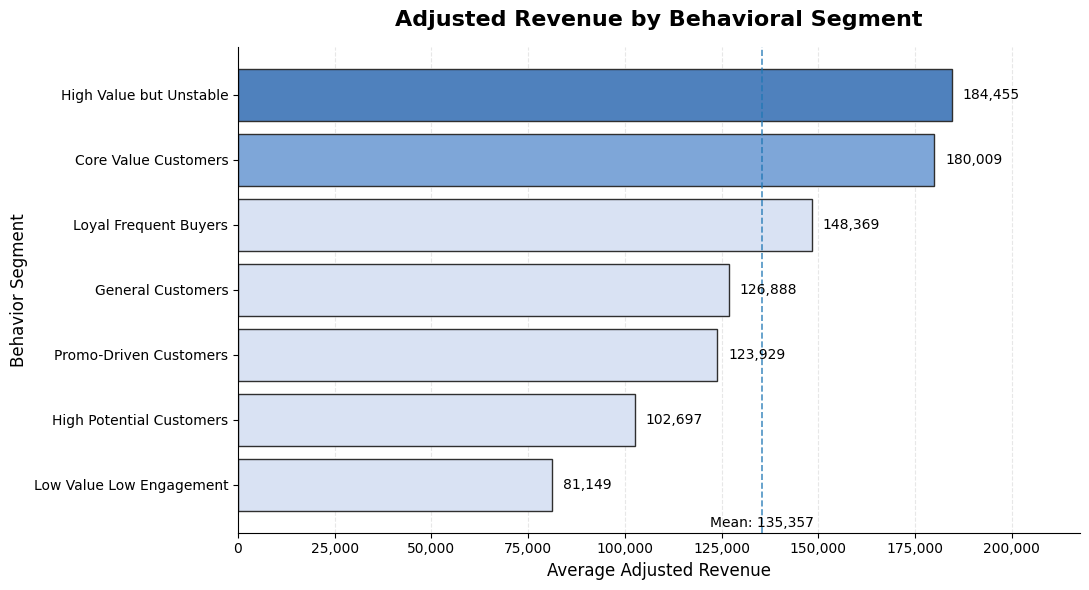

In [ ]:
# Sort values from low to high so the largest segment appears at the top
adjusted_revenue = revenue_quality["adjusted_revenue"].sort_values(ascending=True)

# Highlight the top 2 segments
colors_2 = ["#D9E2F3"] * len(adjusted_revenue)
colors_2[-1] = "#4F81BD"
colors_2[-2] = "#7EA6D8"

# Create figure and axis
fig_2, ax_2 = plt.subplots(figsize=(11, 6), facecolor="white")
ax_2.set_facecolor("white")

# Create horizontal bar_2 chart
bars_2 = ax_2.barh(
    adjusted_revenue.index,
    adjusted_revenue.values,
    color=colors_2,
    edgecolor="#2F2F2F",
    linewidth=1
)

# Set title and axis labels
ax_2.set_title(
    "Adjusted Revenue by Behavioral Segment",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax_2.set_xlabel("Average Adjusted Revenue", fontsize=12)
ax_2.set_ylabel("Behavior Segment", fontsize=12)

# Format x-axis labels with thousand separators
ax_2.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Add subtle gridlines
ax_2.grid(axis="x", linestyle="--", alpha=0.3)
ax_2.set_axisbelow(True)

# Remove unnecessary spines
ax_2.spines["top"].set_visible(False)
ax_2.spines["right"].set_visible(False)

# Add a vertical line for the mean value
mean_val = adjusted_revenue.mean()
ax_2.axvline(mean_val, linestyle="--", linewidth=1.2, alpha=0.8)
ax_2.text(
    mean_val,
    -0.7,
    f"Mean: {mean_val:,.0f}",
    ha="center",
    va="bottom",
    fontsize=10
)

# Add value labels at the end of each bar
offset = adjusted_revenue.max() * 0.015
for bar_2, value_2 in zip(bars, adjusted_revenue.values):
    ax_2.text(
        value_2 + offset,
        bar_2.get_y() + bar_2.get_height() / 2,
        f"{value_2:,.0f}",
        va="center",
        ha="left",
        fontsize=10
    )

# Add extra space on the right for labels
ax_2.set_xlim(0, adjusted_revenue.max() * 1.18)

plt.tight_layout()
plt.show()

**Insight:**

* **Healthy Revenue**
  = revenue that is relatively strong, stable, and less affected by leakage

* **Revenue with Leakage Pressure**
  = revenue that may look good on the surface, but is under pressure because of issues such as:

  * **high return rate**
  * **high cart abandonment**
  * **high coupon dependency**
  * **weaker risk-adjusted value**

---

**Segments generating **Healthy Revenue****

Based on the output, there are **2 segments** classified as **Healthy Revenue**:

**1. **Core Value Customers****

* adjusted_revenue = **180,008.72**
* return_rate = **37.68**
* cart_abandonment = **20.64**
* risk_adjusted_value = **159,984.88**

This is the strongest revenue-quality segment because it combines:

* high revenue
* lower return behavior
* much lower cart abandonment
* the highest risk-adjusted value

---

**2. **General Customers****

* adjusted_revenue = **126,888.33**
* return_rate = **49.72**
* cart_abandonment = **39.54**
* risk_adjusted_value = **81,131.13**

This segment is not as strong as Core Value Customers, but it still falls into the healthy category because:

* revenue is still solid
* return and abandonment levels are more manageable than in several other segments
* it is also the largest segment by customer count

---

**Segments showing **Leakage Pressure****

The following segments are classified as **Revenue with Leakage Pressure**:

**1. **High Value but Unstable****

* adjusted_revenue = **184,455.38**
* return_rate = **60.81**
* cart_abandonment = **58.59**

Revenue is very high, but:

* returns are very high
* abandonment is very high

**This is a high-value segment, but the revenue quality is weak.**
Revenue is strong, but it is under significant leakage pressure.

---

**2. **Loyal Frequent Buyers****

* adjusted_revenue = **148,368.96**
* return_rate = **52.03**
* cart_abandonment = **43.91**

Even though this segment is loyal and active, it still shows leakage pressure because:

* return rate is high
* cart abandonment is also high

**This segment is still important, but its revenue is not as clean or stable as the healthy-revenue segments.**

---

**3. **Promo-Driven Customers****

* adjusted_revenue = **123,929.09**
* return_rate = **50.32**
* cart_abandonment = **40.46**
* coupon_dependency = **0.01** → highest

This segment is heavily influenced by promotions and incentives, which makes:

* revenue quality weaker
* value more dependent on discounts
* leakage risk higher

**Revenue from this segment is less healthy because it is too dependent on promotions.**

---

**4. **High Potential Customers****

* adjusted_revenue = **102,697.49**
* return_rate = **44.80**
* cart_abandonment = **31.55**

This segment has good potential, but still shows signs of leakage pressure.

**This segment is not yet in the healthy-revenue group, but it is still attractive because of its growth potential.**

---

**5. **Low Value Low Engagement****

* adjusted_revenue = **81,148.81**
* return_rate = **51.04**
* cart_abandonment = **41.23**
* risk_adjusted_value = **21,827.60**


This segment is weak across multiple dimensions:

* low value
* low engagement
* leakage is still present

**This is the weakest revenue-quality segment and the lowest business priority.**

---

**Segments generating healthy revenue:**

* **Core Value Customers**
* **General Customers**

**Segments showing leakage pressure:**

* **High Value but Unstable**
* **Loyal Frequent Buyers**
* **Promo-Driven Customers**
* **High Potential Customers**
* **Low Value Low Engagement**

---

**Most important insight**

**1. High revenue does not always mean healthy revenue**

The clearest example is:

* **High Value but Unstable** has the highest adjusted revenue
* but it is still labeled **Revenue with Leakage Pressure**

High revenue alone is not enough. If return and abandonment are high, revenue quality is still weak.

---

**2. The best segment is not the one with the biggest revenue, but the one with the best balance**

**Core Value Customers** stand out because they combine:

* high revenue
* low leakage
* stable value

The best segment is not just the one making money, but the one protecting revenue quality.

---

**3. Promotions and loyalty do not automatically mean healthy revenue**

* **Promo-Driven Customers** still show leakage pressure
* **Loyal Frequent Buyers** also show leakage pressure

Being active, loyal, or responsive does not automatically mean the revenue is high quality.

---

**Final conclusion**

**The segments generating healthy revenue are Core Value Customers and General Customers, because their revenue is relatively more stable and exposed to less leakage.**
In contrast, **High Value but Unstable, Loyal Frequent Buyers, Promo-Driven Customers, High Potential Customers, and Low Value Low Engagement** show **leakage pressure**, because their revenue is more exposed to instability through higher returns, higher abandonment, or stronger promotion dependency.

---

## **Retention Risk Scoring and Flagging**

---

**Business question:**
Which customers show early retention risk?

---

This project does not claim to measure true observed churn. Instead, it builds a practical **retention risk framework** based on early warning signals such as:

- risk score,
- return behavior,
- cart abandonment,
- coupon dependency,
- stability weakness,
- and weaker retention strength.

---

### **Retention Risk Scoring  Theoretical**

---

In [ ]:
# Create a helper function for single-column Min-Max scaling
def minmax_scaler_series(series):
    scaler = MinMaxScaler(feature_range=(0, 1))
    return scaler.fit_transform(series.to_frame()).flatten()

# Retention risk score calculation
df_segment["risk_score_norm"] = minmax_scaler_series(df_segment["risk_score"])
df_segment["abandonment_norm"] = minmax_scaler_series(df_segment["cart_abandonment_rate"])
df_segment["checkout_abandonment_norm"] = minmax_scaler_series(df_segment["checkout_abandonments_per_month"])
df_segment["return_rate_norm"] = minmax_scaler_series(df_segment["return_rate"])
df_segment["coupon_dependency_norm"] = minmax_scaler_series(df_segment["coupon_dependency"])
df_segment["churn_proxy_norm"] = minmax_scaler_series(df_segment["churn_proxy"])
df_segment["stability_inverse"] = 1 - minmax_scaler_series(df_segment["stability_score"])
df_segment["retention_strength_inverse"] = 1 - minmax_scaler_series(df_segment["retention_strength"])

df_segment["retention_risk_score"] = (
    0.22 * df_segment["risk_score_norm"] +
    0.16 * df_segment["abandonment_norm"] +
    0.12 * df_segment["checkout_abandonment_norm"] +
    0.14 * df_segment["return_rate_norm"] +
    0.12 * df_segment["coupon_dependency_norm"] +
    0.10 * df_segment["churn_proxy_norm"] +
    0.07 * df_segment["stability_inverse"] +
    0.07 * df_segment["retention_strength_inverse"]
)

q1_1 = df_segment["retention_risk_score"].quantile(0.50)
q2_1 = df_segment["retention_risk_score"].quantile(0.80)
q3_1 = df_segment["retention_risk_score"].quantile(0.95)

C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_CcZR_.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["risk_score_norm"] = minmax_scaler_series(df_segment["risk_score"])
C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_CcZR_.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["abandonment_norm"] = minmax_scaler_series(df_segment["cart_abandonment_rate"])
C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_CcZR_.py:9: SettingWithCopyWarning: 
A valu

**Insight:**

**1. **Min-Max scaling****

Each variable is transformed into a **0–1 range** so they can be combined fairly, since their original units are different.

For example:

* `risk_score`
* `return_rate`
* `checkout_abandonments_per_month`

do not naturally operate on the same scale.

Without normalization, variables with larger numeric ranges could dominate the final score.
Min-Max scaling ensures that each component contributes on a comparable basis.

---

**2. **Weighted composite score****

The `retention_risk_score` is calculated as a **weighted sum** of several risk-related indicators:

* `risk_score`
* `cart_abandonment_rate`
* `checkout_abandonments_per_month`
* `return_rate`
* `coupon_dependency`
* `churn_proxy`
* `stability_score` (inverted)
* `retention_strength` (inverted)

Theoretically, this is a **rule-based scoring model**, where multiple business-relevant signals are combined into one overall retention risk measure.

Higher weights are assigned to variables considered more important, such as:

* core risk level
* abandonment behavior
* return behavior

---

**3. **Inverse transformation****

`stability_score` and `retention_strength` are reversed using:

* `1 - normalized value`

because conceptually:

* higher `stability_score` means **lower** risk
* higher `retention_strength` means **lower** risk

They are inverted so that all variables follow the same direction:

> **higher values consistently mean higher retention risk**

This makes the final score easier to interpret.

---

**4. **Quantile-based thresholds****

After the continuous score is created, quantiles are used:

* 50%
* 80%
* 95%

to define risk levels.

The theoretical reason is that a continuous risk score becomes more actionable when it is converted into operational categories.
Quantiles help classify customers based on **relative risk**, rather than fixed cutoffs.

This is useful in customer analytics because the score distribution is often not normal, and relative thresholds are usually more practical.

---

### **Risk Scoring and Flagging**

---

In [ ]:
# Define function to assign risk flags based on quantiles
def assign_risk_flag(score):
    if score >= q3_1:
        return "Critical Risk"
    elif score >= q2_1:
        return "At Risk"
    elif score >= q1_1:
        return "Watchlist"
    else:
        return "Stable"

df_segment["retention_risk_flag"] = df_segment["retention_risk_score"].apply(assign_risk_flag)
df_segment[["retention_risk_score", "retention_risk_flag"]].head()

C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_tZnO_.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["retention_risk_flag"] = df_segment["retention_risk_score"].apply(assign_risk_flag)


,retention_risk_score,retention_risk_flag
0,0.213844,Stable
1,0.347483,Stable
2,0.308150,Stable
3,0.481282,Watchlist
4,0.291163,Stable


In [ ]:
# Analyze retention risk distribution
risk_distribution = (
    df_segment.groupby("retention_risk_flag")
      .agg(
          customers=("user_id", "count"),
          avg_monthly_spend=("monthly_spend", "mean"),
          avg_risk_adjusted_value=("risk_adjusted_value", "mean"),
          avg_return_rate=("return_rate", "mean"),
          avg_cart_abandonment=("cart_abandonment_rate", "mean"),
          avg_coupon_dependency=("coupon_dependency", "mean")
      )
      .sort_index()
)

# Calculate customer share percentage for each risk category
risk_distribution["customer_share_pct"] = 100 * risk_distribution["customers"] / len(df_segment)
risk_distribution.round(2)

,customers,avg_monthly_spend,avg_risk_adjusted_value,avg_return_rate,avg_cart_abandonment,avg_coupon_dependency,customer_share_pct
retention_risk_flag,,,,,,,
At Risk,103947,2440.07,42286.68,65.47,65.80,0.0,15.0
Critical Risk,34649,2265.98,24551.83,80.40,72.50,0.0,5.0
Stable,346489,2552.62,92963.13,40.28,22.50,0.0,50.0
Watchlist,207893,2483.31,59444.20,53.42,51.36,0.0,30.0


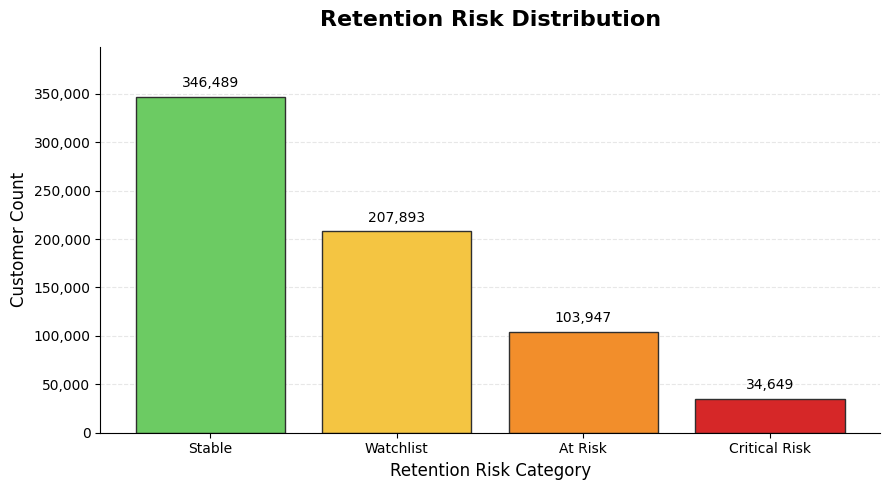

In [ ]:
# Define the desired order of risk categories
risk_order = ["Stable", "Watchlist", "At Risk", "Critical Risk"]

# Count customers in each risk category and preserve the custom order
risk_counts = (
    df_segment["retention_risk_flag"]
    .value_counts()
    .reindex(risk_order)
    .fillna(0)
)

# Define colors by risk severity
colors_3 = ["#6CCB63", "#F4C542", "#F28E2B", "#D62728"]

# Create figure and axis
fig_3, ax_3 = plt.subplots(figsize=(9, 5), facecolor="white")
ax_3.set_facecolor("white")

# Create bar chart
bars_3 = ax_3.bar(
    risk_counts.index,
    risk_counts.values,
    color=colors_3,
    edgecolor="#2F2F2F",
    linewidth=1
)

# Set title and axis labels
ax_3.set_title(
    "Retention Risk Distribution",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax_3.set_xlabel("Retention Risk Category", fontsize=12)
ax_3.set_ylabel("Customer Count", fontsize=12)

# Format y-axis labels with thousand separators
ax_3.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Add subtle horizontal gridlines
ax_3.grid(axis="y", linestyle="--", alpha=0.3)
ax_3.set_axisbelow(True)

# Remove unnecessary spines
ax_3.spines["top"].set_visible(False)
ax_3.spines["right"].set_visible(False)

# Rotate x-axis labels slightly
plt.xticks(rotation=0)

# Add value labels above each bar
offset_2 = risk_counts.max() * 0.02
for bar_3, value_3 in zip(bars_3, risk_counts.values):
    ax_3.text(
        bar_3.get_x() + bar_3.get_width() / 2,
        bar_3.get_height() + offset_2,
        f"{int(value_3):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Add extra headroom for labels
ax_3.set_ylim(0, risk_counts.max() * 1.15)

plt.tight_layout()
plt.show()

**Insight:**

****1. Watchlist customers****

This is the clearest **early warning group**.

Data:

* **207,893 customers**
* **30%** of the customer base
* Avg monthly spend = **2,483.31**
* Avg risk-adjusted value = **59,444.20**
* Avg return rate = **53.42**
* Avg cart abandonment = **51.36**

This group is not yet as severe as **At Risk** or **Critical Risk**, but it already shows clear warning signs:

* return rate is becoming high
* cart abandonment is also high
* risk-adjusted value has already dropped meaningfully compared with **Stable**

**Watchlist customers are the main segment showing early retention risk.**
They can still be recovered, but they already need attention.

---

****2. At Risk customers****

This is a more advanced level of risk.

Data:

* **103,947 customers**
* **15%**
* Avg monthly spend = **2,440.07**
* Avg risk-adjusted value = **42,286.68**
* Avg return rate = **65.47**
* Avg cart abandonment = **65.80**

This group is already showing much more serious problems:

* return rate is very high
* abandonment is very high
* risk-adjusted value has dropped sharply

**At Risk customers are no longer an early signal — they are already in a stronger risk state.**

---

****3. Critical Risk customers****

This is the most severe group.

Data:

* **34,649 customers**
* **5%**
* Avg monthly spend = **2,265.98**
* Avg risk-adjusted value = **24,551.83**
* Avg return rate = **80.40**
* Avg cart abandonment = **72.50**

This group is highly unstable:

* extremely high return rate
* very high abandonment
* much weaker value

**Critical Risk customers are the most problematic retention group, not an early-risk segment.**

---

****4. Stable customers****

This is the safest group.

Data:

* **346,489 customers**
* **50%**
* Avg monthly spend = **2,552.62**
* Avg risk-adjusted value = **92,963.13**
* Avg return rate = **40.28**
* Avg cart abandonment = **22.50**

This group is the healthiest:

* highest risk-adjusted value
* lowest return and abandonment levels

**Stable customers do not show early retention risk.**

---

****Watchlist customers****

because they:

* make up a large share of the base (**30%**)
* are not yet as severe as At Risk or Critical Risk
* but already show clear warning signs:

  * higher return rate
  * higher cart abandonment
  * lower risk-adjusted value

---

**Key insight**

**The most important early retention risk sits in the **Watchlist** group

* **Stable** customers are still healthy
* **At Risk** and **Critical Risk** are already more serious
* **Watchlist** is the point where the business still has a strong chance to intervene early

So from a business perspective:

**Watchlist is the most important group for prevention before customers move into At Risk or Critical Risk.**

---

## **Stable vs At-Risk Comparison**

---

**Business question:**
How do stable customers differ from risky customers?

---

In [ ]:
# Stability vs risk analysis
stable_vs_risk = (
    df_segment[df_segment["retention_risk_flag"].isin(["Stable", "At Risk", "Critical Risk"])]
      .groupby("retention_risk_flag")
      .agg(
          customers=("user_id", "count"),
          avg_monthly_spend=("monthly_spend", "mean"),
          avg_weekly_purchases=("weekly_purchases", "mean"),
          avg_engagement_score=("engagement_score", "mean"),
          avg_adjusted_revenue=("adjusted_revenue", "mean"),
          avg_revenue_efficiency=("revenue_efficiency", "mean"),
          avg_return_rate=("return_rate", "mean"),
          avg_cart_abandonment=("cart_abandonment_rate", "mean"),
          avg_coupon_dependency=("coupon_dependency", "mean"),
          avg_brand_loyalty_score=("brand_loyalty_score", "mean"),
          avg_retention_strength=("retention_strength", "mean")
      )
)

stable_vs_risk.round(2)

,customers,avg_monthly_spend,avg_weekly_purchases,avg_engagement_score,avg_adjusted_revenue,avg_revenue_efficiency,avg_return_rate,avg_cart_abandonment,avg_coupon_dependency,avg_brand_loyalty_score,avg_retention_strength
retention_risk_flag,,,,,,,,,,,
At Risk,103947,2440.07,10.53,0.50,120821.04,3.50,65.47,65.8,0.0,5.01,-32.71
Critical Risk,34649,2265.98,10.49,0.44,100952.07,3.29,80.40,72.5,0.0,5.01,-32.00
Stable,346489,2552.62,10.50,0.54,144433.06,3.71,40.28,22.5,0.0,5.00,-11.95


**Insight:**

**Stable customers are stronger overall**

Compared with risky customers, **Stable customers** show:

* **higher monthly spend** (**2552.62** vs **2440.07** and **2265.98**)
* **higher engagement** (**0.54** vs **0.50** and **0.44**)
* **higher adjusted revenue** (**144,433.06** vs **120,821.04** and **100,952.07**)
* **better revenue efficiency** (**3.71** vs **3.50** and **3.29**)

This means stable customers are more valuable and more efficient from a business perspective.

---

**The biggest difference is in leakage behavior**

Risky customers are much worse in:

* **return rate**

  * Stable: **40.28**
  * At Risk: **65.47**
  * Critical Risk: **80.40**

* **cart abandonment**

  * Stable: **22.50**
  * At Risk: **65.80**
  * Critical Risk: **72.50**

This shows that risky customers are much more likely to lose value through failed or reversed transactions.

---

**Weekly purchase frequency is almost the same**

* Stable: **10.50**
* At Risk: **10.53**
* Critical Risk: **10.49**

So the main difference is **not** how often they buy.
The main difference is **how healthy and stable their behavior is**.

---

**Retention strength is much weaker in risky groups**

* Stable: **-11.95**
* At Risk: **-32.71**
* Critical Risk: **-32.00**

This confirms that risky customers are much less stable from a retention point of view.

---

**Conclusion**

**Stable customers generate better and safer revenue, while risky customers show much more leakage and weaker retention quality.**
The main difference is not purchase frequency, but **engagement, return behavior, cart abandonment, and retention strength**.

---

## **Customer Segment Data-Driven**

---

**Business question:**
Can a fully data-driven method reveal customer segments without predefined rules?

---

In [ ]:
# Define features for clustering
clustering_features = [
    "monthly_spend",
    "weekly_purchases",
    "engagement_score",
    "browse_to_buy_ratio",
    "cart_abandonment_rate",
    "return_rate",
    "coupon_dependency",
    "risk_score",
    "loyalty_strength",
    "risk_adjusted_value"
]

# Prepare data for clustering
X = df_segment[clustering_features].copy()

In [ ]:
df_segment[clustering_features].head()

,monthly_spend,weekly_purchases,engagement_score,browse_to_buy_ratio,cart_abandonment_rate,return_rate,coupon_dependency,risk_score,loyalty_strength,risk_adjusted_value
0,2405,4,0.5170,12,0,50,0.001247,0.264000,0.890,109744.960000
1,3651,13,0.4810,93,28,37,0.000000,0.373444,0.450,123527.934000
2,2045,10,0.7345,68,14,53,0.000000,0.422222,0.270,38991.333333
3,1611,16,0.5350,74,11,98,0.001241,0.564889,0.355,18225.064000
4,3107,8,0.4835,28,28,34,0.000644,0.232444,0.370,233709.920889


In [ ]:
# Handle any remaining missing values by filling with median
X.head()

,monthly_spend,weekly_purchases,engagement_score,browse_to_buy_ratio,cart_abandonment_rate,return_rate,coupon_dependency,risk_score,loyalty_strength,risk_adjusted_value
0,2405,4,0.5170,12,0,50,0.001247,0.264000,0.890,109744.960000
1,3651,13,0.4810,93,28,37,0.000000,0.373444,0.450,123527.934000
2,2045,10,0.7345,68,14,53,0.000000,0.422222,0.270,38991.333333
3,1611,16,0.5350,74,11,98,0.001241,0.564889,0.355,18225.064000
4,3107,8,0.4835,28,28,34,0.000644,0.232444,0.370,233709.920889


In [ ]:
# Standardize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Faster KMeans evaluation
k_results = []
for k in [2, 3, 4, 5]:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    k_results.append((k, score))

kmeans_eval = pd.DataFrame(k_results, columns=["k", "silhouette_score"]) \
    .sort_values("silhouette_score", ascending=False)

kmeans_eval

,k,silhouette_score
0,2,0.142606
1,3,0.134655
2,4,0.124653
3,5,0.122053


In [ ]:
best_k = kmeans_eval.iloc[0]["k"]
best_score = kmeans_eval.iloc[0]["silhouette_score"]
print(f"Best k based on silhouette score: {best_k} with score {best_score:.4f}")

Best k based on silhouette score: 2.0 with score 0.1426


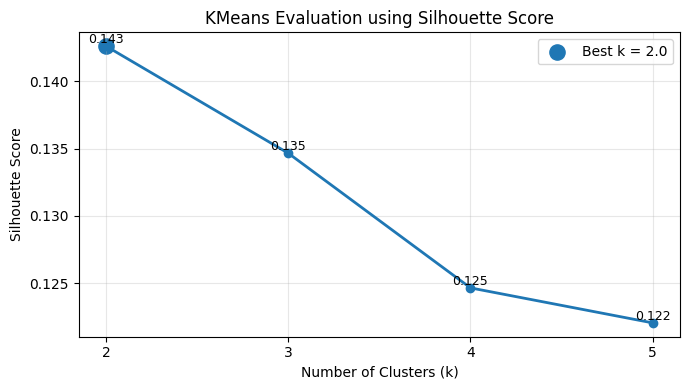

In [ ]:
# Visualize silhouette scores for different k values
plt.figure(figsize=(7, 4))
plt.plot(
    kmeans_eval["k"],
    kmeans_eval["silhouette_score"],
    marker="o",
    linewidth=2
)

plt.scatter(best_k, best_score, s=120, label=f"Best k = {best_k}")

for x, y in zip(kmeans_eval["k"], kmeans_eval["silhouette_score"]):
    plt.text(x, y, f"{y:.3f}", ha="center", va="bottom", fontsize=9)

plt.title("KMeans Evaluation using Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(kmeans_eval["k"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Insight:**

KMeans clustering was evaluated using silhouette score across 2 to 5 clusters. The highest score was obtained at k=2 (0.143), indicating that two clusters provide the best separation among the tested options. However, the overall silhouette values remain low, suggesting that customer groups in this dataset are not strongly separated in a natural cluster structure. This implies that while clustering can provide a coarse grouping, business-rule segmentation may be more interpretable and actionable for customer analysis.

---

## **Business Priority Matrix**

---

**Business question:**
How should the business prioritize each customer after combining segment and risk views?

---

In [ ]:
# Assign business priority based on behavior segment and retention risk
def assign_business_priority(row):
    seg = row["behavior_segment"]
    risk = row["retention_risk_flag"]

    if seg in ["Core Value Customers", "Loyal Frequent Buyers"] and risk == "Stable":
        return "Protect and Retain"
    elif seg == "High Value but Unstable" or risk == "Critical Risk":
        return "Urgent Retention Intervention"
    elif seg == "High Potential Customers" and risk in ["Stable", "Watchlist"]:
        return "Upsell and Value Expansion"
    elif seg == "Promo-Driven Customers":
        return "Discount Control and Margin Protection"
    elif seg == "Low Value Low Engagement":
        return "Low-Cost Automation"
    elif risk == "At Risk":
        return "Retention Watchlist"
    else:
        return "Maintain and Monitor"

In [ ]:
# Apply the function to assign business priority
df_segment["business_priority"] = df_segment.apply(assign_business_priority, axis=1)

C:\Users\user\AppData\Local\Temp\marimo_23000\__marimo__cell_woaO_.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["business_priority"] = df_segment.apply(assign_business_priority, axis=1)


In [ ]:
# Create summary of business priority groups
priority_summary = (
    df_segment.groupby("business_priority")
      .agg(
          customers=("user_id", "count"),
          customer_share_pct=("user_id", lambda x: 100 * len(x) / len(df)),
          avg_monthly_spend=("monthly_spend", "mean"),
          avg_engagement=("engagement_score", "mean"),
          avg_retention_risk=("retention_risk_score", "mean"),
          avg_adjusted_revenue=("adjusted_revenue", "mean")
      )
      .sort_values("customers", ascending=False)
)

priority_summary.round(2)

,customers,customer_share_pct,avg_monthly_spend,avg_engagement,avg_retention_risk,avg_adjusted_revenue
business_priority,,,,,,
Maintain and Monitor,243522,35.14,2984.44,0.53,0.39,134855.26
Discount Control and Margin Protection,198008,28.57,1153.03,0.53,0.42,125503.74
Urgent Retention Intervention,91699,13.23,3345.78,0.49,0.60,156201.32
Protect and Retain,70835,10.22,3655.37,0.57,0.29,174981.11
Retention Watchlist,42278,6.10,2837.85,0.52,0.60,101818.39
Upsell and Value Expansion,23462,3.39,2780.97,0.66,0.36,103392.13
Low-Cost Automation,23174,3.34,1157.51,0.41,0.43,82815.74


**Insight:**

**Protect and Retain (10.22%)**

These are the best customers: high spend, high engagement, low risk, and the highest adjusted revenue.
Business meaning: this is the premium customer group that should be protected because it generates the strongest and most stable value.

**Urgent Retention Intervention (13.23%)**

These customers are still valuable, but their retention risk is high.
Business meaning: this is the most dangerous segment to ignore, because the business could lose customers who still generate significant revenue.

**Upsell and Value Expansion (3.39%)**

This segment has the highest engagement and relatively manageable risk.
Business meaning: this is the best group for upsell, cross-sell, and personalized value expansion.

**Discount Control and Margin Protection (28.57%)**

These customers are more promotion-driven: the group is large, but spend is relatively low.
Business meaning: the main goal here is not only to drive sales, but also to protect margins and avoid over-reliance on discounts.

**Retention Watchlist (6.10%)**

These customers are starting to show retention risk, but are not yet in the most severe stage.
Business meaning: this is the early-warning group that should be monitored and addressed before it becomes a bigger retention problem.

**Low-Cost Automation (3.34%)**

This group has low spend, low engagement, and the weakest adjusted revenue.
Business meaning: this segment does not justify expensive treatment, so it should be managed through low-cost automation.

**Maintain and Monitor (35.14%)**

This is the largest group, with fairly healthy performance and moderate risk.
Business meaning: they do not require urgent intervention, but they still matter because of their large size and steady contribution.

**Overall business conclusion:**

The main takeaway is that not all customers should be treated the same way.
Some customers should be:

- Protected because they are highly valuable,
- Saved because they are valuable but becoming risky,
- Developed because they have growth potential, or simply managed efficiently because their contribution is lower.

---

## **Export File**

---

**Business question:**
What final outputs can the business use immediately?

---

In [ ]:
# Create the final customer table for CRM dashboard
final_customer_table = df_segment[
    [
        "user_id",
        "monthly_spend",
        "weekly_purchases",
        "average_order_value",
        "lifetime_value_proxy",
        "risk_adjusted_value",
        "engagement_score",
        "coupon_dependency",
        "cart_abandonment_rate",
        "return_rate",
        "risk_score",
        "stability_score",
        "retention_strength",
        "f_score",
        "m_score",
        "fm_segment",
        "behavior_segment",
        "retention_risk_score",
        "retention_risk_flag",
        "business_priority",
        "loyalty_program_member",
        "premium_subscription",
        "country",
        "income_level"
    ]
].copy()

final_customer_table.head()

,user_id,monthly_spend,weekly_purchases,average_order_value,lifetime_value_proxy,risk_adjusted_value,engagement_score,coupon_dependency,cart_abandonment_rate,return_rate,...,m_score,fm_segment,behavior_segment,retention_risk_score,retention_risk_flag,business_priority,loyalty_program_member,premium_subscription,country,income_level
0,1,2405,4,445,45695,109744.960000,0.5170,0.001247,0,50,...,3,Mid Value Regulars,Loyal Frequent Buyers,0.213844,Stable,Protect and Retain,1,1,Germany,90860
1,2,3651,13,179,29208,123527.934000,0.4810,0.000000,28,37,...,4,Mid Value Regulars,High Value but Unstable,0.347483,Stable,Urgent Retention Intervention,1,0,Japan,35423
2,3,2045,10,26,26585,38991.333333,0.7345,0.000000,14,53,...,3,Mid Value Regulars,High Potential Customers,0.308150,Stable,Upsell and Value Expansion,0,0,India,21467
3,4,1611,16,403,14499,18225.064000,0.5350,0.001241,11,98,...,2,Frequent Low Basket,Promo-Driven Customers,0.481282,Watchlist,Discount Control and Margin Protection,1,0,Canada,41770
4,7,3107,8,83,27963,233709.920889,0.4835,0.000644,28,34,...,4,High Spend Low Frequency,General Customers,0.291163,Stable,Maintain and Monitor,1,0,Germany,62804


In [ ]:
# Create a strategic playbook for each behavior segment
playbook = pd.DataFrame({
    "segment": [
        "Core Value Customers",
        "Loyal Frequent Buyers",
        "High Value but Unstable",
        "Promo-Driven Customers",
        "High Potential Customers",
        "Low Value Low Engagement",
        "General Customers"
    ],
    "main_characteristic": [
        "High value, low leakage, relatively stable",
        "High activity, loyal relationship, repeat-oriented",
        "Strong value but elevated leakage and retention pressure",
        "Dependent on coupons, weaker standalone value quality",
        "Good engagement and room to grow value",
        "Weak value and weak engagement",
        "Average profile without dominant strength or risk"
    ],
    "business_objective": [
        "Protect loyalty and preserve revenue quality",
        "Maintain habit and increase wallet share",
        "Reduce leakage and prevent value decline",
        "Control discount dependence and protect margin",
        "Increase monetization through targeted growth",
        "Maintain efficiently at low cost",
        "Monitor and optimize selectively"
    ],
    "recommended_action": [
        "VIP retention, premium service, personalized appreciation",
        "Cross-sell, membership benefits, frequency reinforcement",
        "Proactive outreach, service recovery, return control, checkout recovery",
        "Reduce blanket discounts, test non-price incentives, tighten promo targeting",
        "Personalized upsell, category expansion, bundle recommendation",
        "Automation-only journeys, low-cost communication, passive nurture",
        "Routine monitoring and light segmentation treatment"
    ]
})

playbook

,segment,main_characteristic,business_objective,recommended_action
0,Core Value Customers,"High value, low leakage, relatively stable",Protect loyalty and preserve revenue quality,"VIP retention, premium service, personalized appreciation"
1,Loyal Frequent Buyers,"High activity, loyal relationship, repeat-oriented",Maintain habit and increase wallet share,"Cross-sell, membership benefits, frequency reinforcement"
2,High Value but Unstable,Strong value but elevated leakage and retention pressure,Reduce leakage and prevent value decline,"Proactive outreach, service recovery, return control, checkout recovery"
3,Promo-Driven Customers,"Dependent on coupons, weaker standalone value quality",Control discount dependence and protect margin,"Reduce blanket discounts, test non-price incentives, tighten promo targeting"
4,High Potential Customers,Good engagement and room to grow value,Increase monetization through targeted growth,"Personalized upsell, category expansion, bundle recommendation"
5,Low Value Low Engagement,Weak value and weak engagement,Maintain efficiently at low cost,"Automation-only journeys, low-cost communication, passive nurture"
6,General Customers,Average profile without dominant strength or risk,Monitor and optimize selectively,Routine monitoring and light segmentation treatment


In [ ]:
# Optional exports
final_customer_table.to_csv("customer_segmentation_retention_kmeans_output.csv", index=False)
priority_summary.to_csv("business_priority_summary.csv")
playbook.to_csv("segment_action_playbook.csv", index=False)

print("Export files created successfully.")

Export files created successfully.


**Insight:**

Dataframe successfully exported

---

## **Overall conclusion**

---

This notebook shows that customers should not be evaluated only by how often they buy and how much they spend. A more useful view comes from combining **value, engagement, revenue quality, leakage behavior, and retention strength** into one structured customer analysis. The dataset and selected feature set were built to support exactly that kind of segmentation, using value, behavior, loyalty, and risk-related variables.

The strongest result is that **the most important customers are not simply the highest spenders, but the customers who create high and stable value**. The composite scoring framework supports this by showing that customer value is concentrated in a smaller high-value group, while behavior is more evenly distributed and leakage signals are moderately present across the base. In other words, value alone is not enough; customer quality also depends on how stable and healthy that value is.

From the segmentation results, **Core Value Customers** emerge as the best segment overall because they combine strong spend, solid engagement, lower leakage, and the strongest risk-adjusted value. By contrast, **High Value but Unstable** customers look attractive on the surface because they generate high revenue, but their return and abandonment behavior makes that revenue much less secure. This means the analysis successfully separates customers with strong value quality from customers whose value is more fragile.

The FM analysis is still useful, but mainly as a starting point. It helps distinguish important commercial patterns such as **high-frequency high-spend customers**, **high-spend low-frequency customers**, and **frequent low-basket customers**. However, FM alone does not fully explain revenue quality or retention risk. It is most useful when combined with engagement, leakage, loyalty, and risk indicators.

One of the most important findings is that **healthy revenue is not the same as high revenue**. The analysis shows that only some segments generate revenue that is both strong and stable. **Core Value Customers** and **General Customers** stand out as the healthiest revenue groups, while segments such as **High Value but Unstable**, **Promo-Driven Customers**, and **Loyal Frequent Buyers** still show leakage pressure because of higher returns, higher cart abandonment, or stronger promotion dependency.

The retention analysis adds another important layer. It shows that the **Watchlist** group is the most important early-warning segment. These customers are not yet in the most severe risk stage, but they already show weaker value quality through higher return behavior, higher cart abandonment, and lower risk-adjusted value than Stable customers. That makes them the best group for early intervention before they move into more serious risk categories. The same framework also shows that Stable customers differ from risky customers less in purchase frequency and more in **engagement, leakage behavior, and retention strength**.

Methodologically, the notebook is also robust. Winsorization was used selectively to reduce the impact of extreme outliers without removing customers from the data, which helps keep segmentation, scoring, and clustering more stable and representative. This is especially important because customer variables such as spend, value, return behavior, and risk often follow skewed distributions.

The clustering results reinforce the same conclusion. KMeans identified **k = 2** as the best option among the tested values, but the silhouette score remained low, which suggests that the customer base does not split into very strong natural clusters. This means **business-rule segmentation is more interpretable and more actionable** than relying only on unsupervised clustering. That makes the behavioral segments and retention-risk groups more useful for CRM and business planning.

---

## **Final Business Takeaway**

---

Overall, this analysis shows that **customer importance should be defined by value quality, stability, and behavioral health, not only by transaction volume**. The business should:

* protect **Core Value Customers** because they generate the strongest and healthiest value,
* stabilize **High Value but Unstable** customers because they generate revenue that is still exposed to leakage,
* develop **High Potential Customers** because they are strong candidates for future value growth,
* reduce discount dependency in **Promo-Driven Customers** to protect margin quality,
* and focus early retention action on the **Watchlist** segment before customers move into more severe risk states.

In short, the notebook meets its aim by turning customer data into a segmentation framework that is both analytically strong and operationally useful: it explains **who creates value, who is leaking value, who is at risk, and what the business should do next**.

---